# NeuralForecast Experiments

Neural baselines. Pure sequence models use `runner_no_exog`; exogenous models use `runner_futr_exog`.

In [1]:
import importlib

import config as shared_config
import experiment
import experiment.config
import experiment.data
import experiment.rolling_forecast.artifacts
import experiment.rolling_forecast.executors
import experiment.rolling_forecast.executors.mlforecast
import experiment.rolling_forecast.executors.neural
import experiment.rolling_forecast.runner
import experiment.rolling_forecast.runtime

importlib.reload(shared_config)
importlib.reload(experiment.config)
importlib.reload(experiment.data)
importlib.reload(experiment.rolling_forecast.artifacts)
importlib.reload(experiment.rolling_forecast.executors.mlforecast)
importlib.reload(experiment.rolling_forecast.executors.neural)
importlib.reload(experiment.rolling_forecast.executors)
importlib.reload(experiment.rolling_forecast.runtime)
importlib.reload(experiment.rolling_forecast.runner)
importlib.reload(experiment)

from experiment import DatasetBuilder, ModelSpec, RollingForecastRunner, RunConfig

In [10]:
prepared_dataset = DatasetBuilder.from_csv(
    csv_path=shared_config.CSV_PATH,
    unique_id=shared_config.UNIQUE_ID,
    remove_last_month=shared_config.REMOVE_LAST_MONTH,
    hist_exog=shared_config.HIST_EXOG_LIST,
    futr_exog=shared_config.FUTR_EXOG_LIST,
)


def build_run_config(*, use_hist_exog: bool, use_futr_exog: bool) -> RunConfig:
    return RunConfig(
        input_size=shared_config.INPUT_SIZE,
        horizon=shared_config.HORIZON,
        split_ratio=shared_config.SPLIT_RATIO,
        sliding_step_size=shared_config.SLIDING_STEP_SIZE,
        use_hist_exog=use_hist_exog,
        use_futr_exog=use_futr_exog,
        save_plots=shared_config.SAVE_PLOTS,
        random_seed=shared_config.RANDOM_SEED,
        early_stop_patience_epochs=shared_config.EARLY_STOP_PATIENCE_EPOCHS,
        ml_early_stopping_rounds=shared_config.ML_EARLY_STOPPING_ROUNDS,
        neural_loss_name=shared_config.NEURAL_LOSS_NAME,
        neural_loss_params=shared_config.NEURAL_LOSS_PARAMS,
        neural_checkpoint_mode=shared_config.CHECKPOINT_MODE,
        save_dir=shared_config.SAVE_DIR,
        plot_forecast=shared_config.PLOT_FORECAST,
        plot_loss=shared_config.PLOT_LOSS,
        plot_loss_name=shared_config.PLOT_LOSS_NAME,
        freq=shared_config.FREQ,
    )

# USE_HIST_EXOG = True
USE_HIST_EXOG = False

NEURAL_MAX_EPOCHS = 100
NEURAL_LEARNING_RATE = 1e-3

run_config_no_exog = build_run_config(
    use_hist_exog=False,
    use_futr_exog=False,
)
run_config_hist_exog = build_run_config(
    use_hist_exog=True,
    use_futr_exog=False,
)
run_config_futr_exog = build_run_config(
    use_hist_exog=False,
    use_futr_exog=True,
)
run_config_both_exog = build_run_config(
    use_hist_exog=True,
    use_futr_exog=True,
)

runner_no_exog = RollingForecastRunner(
    prepared_dataset=prepared_dataset,
    run_config=run_config_no_exog,
)
runner_hist_exog = RollingForecastRunner(
    prepared_dataset=prepared_dataset,
    run_config=run_config_hist_exog,
)
runner_futr_exog = RollingForecastRunner(
    prepared_dataset=prepared_dataset,
    run_config=run_config_futr_exog,
)
runner_both_exog = RollingForecastRunner(
    prepared_dataset=prepared_dataset,
    run_config=run_config_both_exog,
)


def run_model(model_spec: ModelSpec, runner: RollingForecastRunner):
    result = runner.run(model_spec)
    print(result.summary())
    print(f"rolling_raw_path: {result.rolling_raw_path}")
    return result

Seed set to 2026


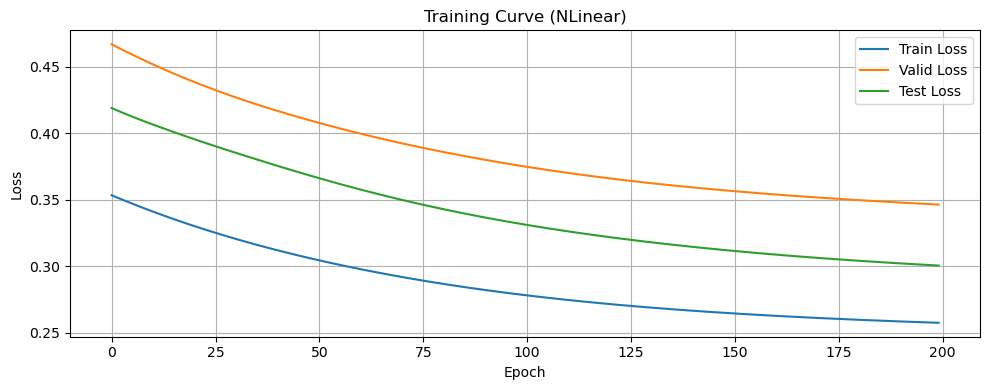

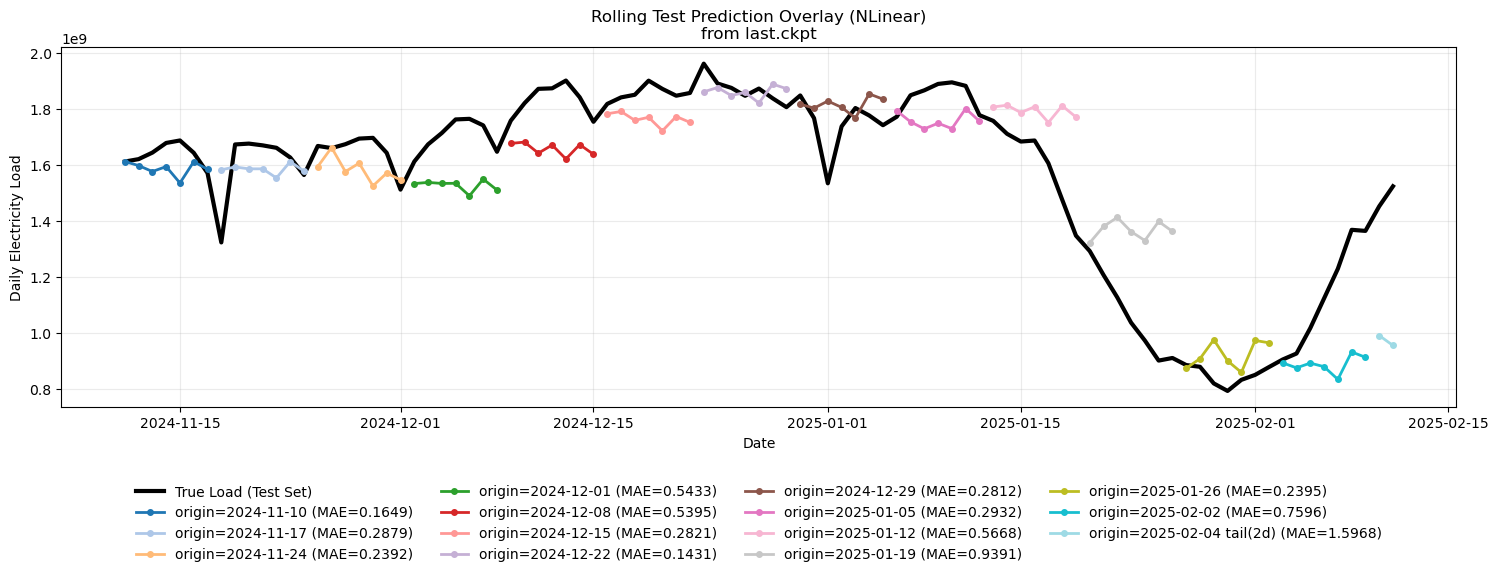

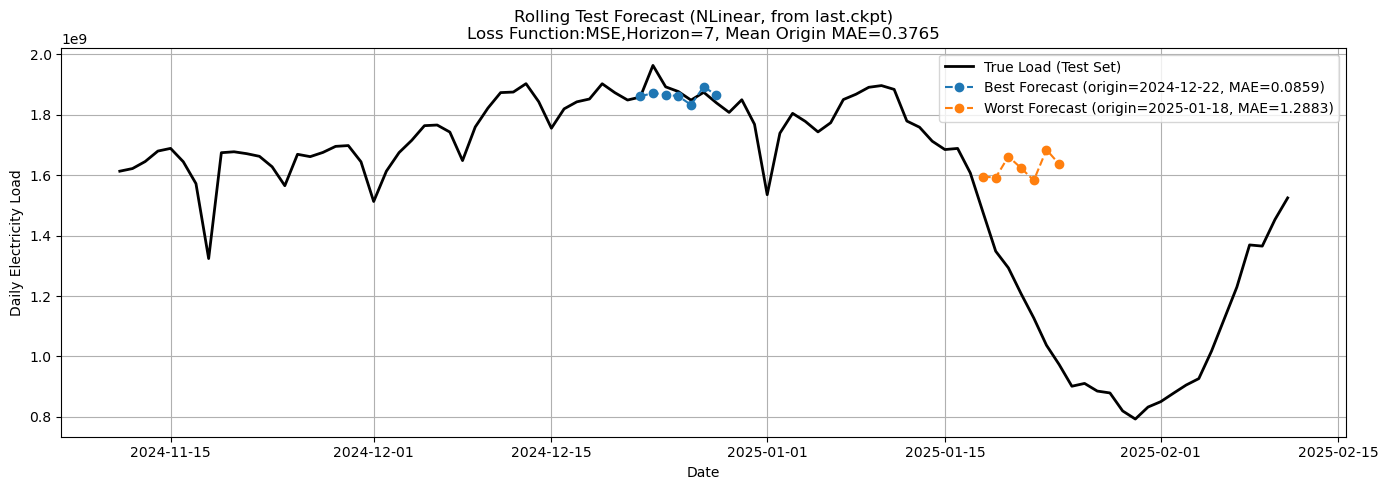

{'model_name': 'NLinear', 'val_overall_mape': 8.50567900292465, 'overall_mape': 9.136538684796214, 'skipped': False, 'skip_reason': None, 'artifact_dir': 'artifacts\\NLinear_no_feat\\20260420_153426', 'best_model_path': 'artifacts\\NLinear_no_feat\\20260420_153426\\checkpoints\\last.ckpt', 'val_best_model_path': 'artifacts\\NLinear_no_feat\\20260420_153426\\checkpoints\\val_best.ckpt', 'test_best_model_path': None, 'rolling_raw_path': 'artifacts\\NLinear_no_feat\\20260420_153426\\rolling_test_raw.csv', 'overlay_plot_path': 'artifacts\\NLinear_no_feat\\20260420_153426\\rolling_test_overlay.png'}
rolling_raw_path: artifacts\NLinear_no_feat\20260420_153426\rolling_test_raw.csv


In [ ]:
# from neuralforecast.models import NLinear

# nlinear_spec = ModelSpec(
#     name="NLinear",
#     model_type="neural",
#     model_cls=NLinear,
#     model_params={
#         "max_epochs": NEURAL_MAX_EPOCHS,
#         "learning_rate": NEURAL_LEARNING_RATE,
#     },
#     supports_hist_exog=False,
#     supports_future_exog=False,
# )

# nlinear_result = run_model(nlinear_spec, runner_no_exog)

In [ ]:
# from neuralforecast.models import DLinear

# dlinear_spec = ModelSpec(
#     name="DLinear",
#     model_type="neural",
#     model_cls=DLinear,
#     model_params={
#         "moving_avg_window": 7,
#         "max_epochs": NEURAL_MAX_EPOCHS,
#         "learning_rate": NEURAL_LEARNING_RATE,
#     },
#     supports_hist_exog=False,
#     supports_future_exog=False,
# )

# dlinear_result = run_model(dlinear_spec, runner_no_exog)

Seed set to 2026


SystemExit: 1

d:\miniconda\envs\dl\Lib\site-packages\IPython\core\interactiveshell.py:3585: UserWarning: To exit: use 'exit', 'quit', or Ctrl-D.
  warn("To exit: use 'exit', 'quit', or Ctrl-D.", stacklevel=1)


In [ ]:
# from neuralforecast.models import NBEATS

# nbeats_spec = ModelSpec(
#     name="NBEATS",
#     model_type="neural",
#     model_cls=NBEATS,
#     model_params={
#         "max_epochs": NEURAL_MAX_EPOCHS,
#         "learning_rate": NEURAL_LEARNING_RATE,
#     },
#     supports_hist_exog=False,
#     supports_future_exog=False,
# )

# nbeats_result = run_model(nbeats_spec, runner_no_exog)

Seed set to 2026


SystemExit: 1

d:\miniconda\envs\dl\Lib\site-packages\IPython\core\interactiveshell.py:3585: UserWarning: To exit: use 'exit', 'quit', or Ctrl-D.
  warn("To exit: use 'exit', 'quit', or Ctrl-D.", stacklevel=1)


Seed set to 2026


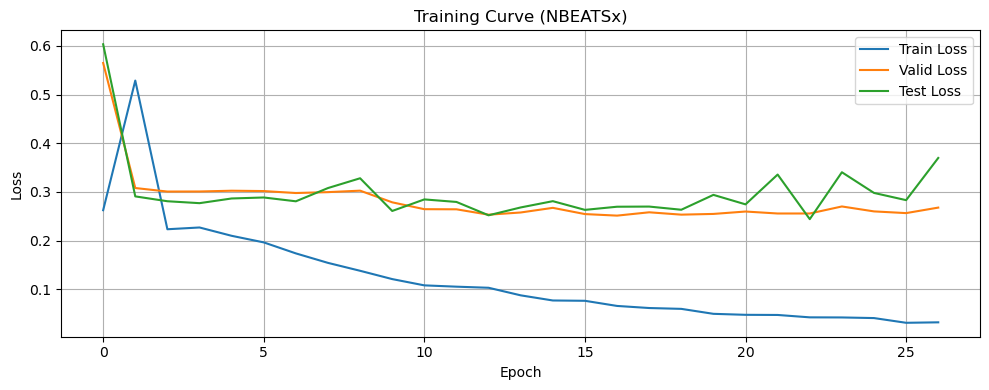

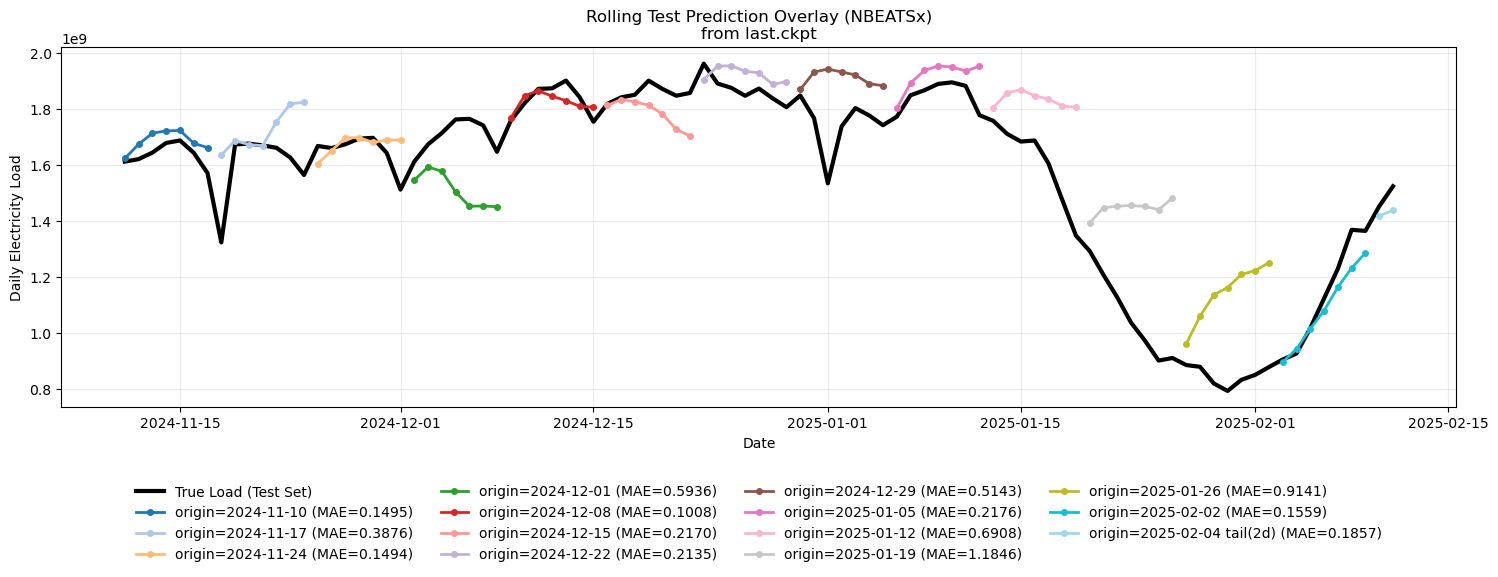

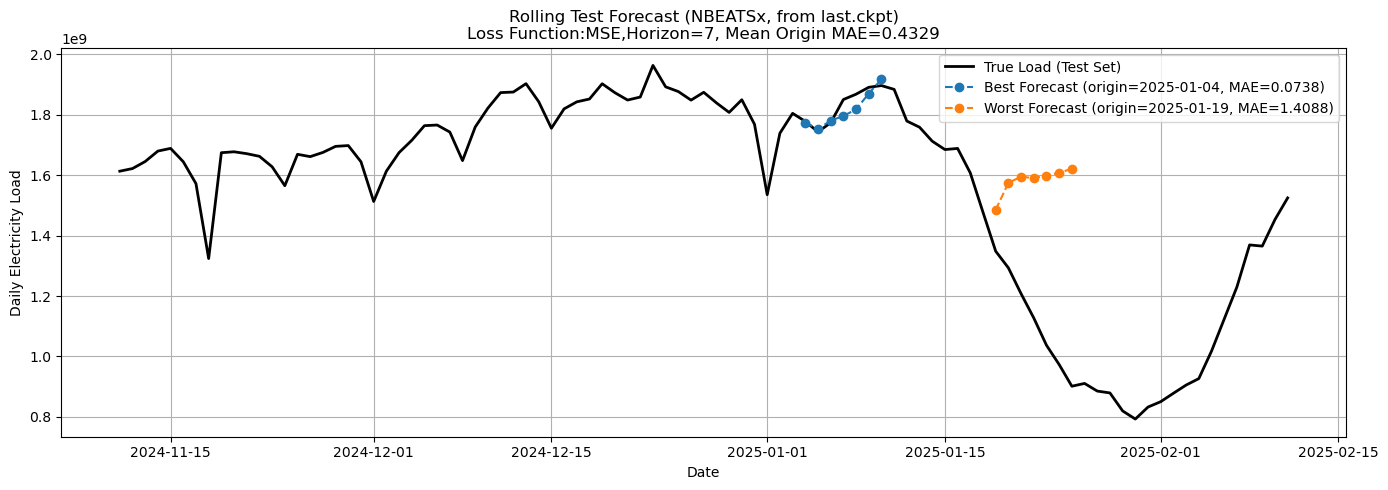

{'model_name': 'NBEATSx', 'val_overall_mape': 7.360015292571982, 'overall_mape': 11.15621803254531, 'skipped': False, 'skip_reason': None, 'artifact_dir': 'artifacts\\NBEATSx_both_feat\\20260420_161413', 'best_model_path': 'artifacts\\NBEATSx_both_feat\\20260420_161413\\checkpoints\\last.ckpt', 'val_best_model_path': 'artifacts\\NBEATSx_both_feat\\20260420_161413\\checkpoints\\val_best.ckpt', 'test_best_model_path': None, 'rolling_raw_path': 'artifacts\\NBEATSx_both_feat\\20260420_161413\\rolling_test_raw.csv', 'overlay_plot_path': 'artifacts\\NBEATSx_both_feat\\20260420_161413\\rolling_test_overlay.png'}
rolling_raw_path: artifacts\NBEATSx_both_feat\20260420_161413\rolling_test_raw.csv


In [11]:
from neuralforecast.models import NBEATSx

nbeatsx_spec = ModelSpec(
    name="NBEATSx",
    model_type="neural",
    model_cls=NBEATSx,
    model_params={
        "max_epochs": NEURAL_MAX_EPOCHS,
        "learning_rate": NEURAL_LEARNING_RATE,
    },
    supports_hist_exog=True,
    supports_future_exog=True,
)

nbeatsx_result = run_model(nbeatsx_spec, runner_both_exog)

Seed set to 2026


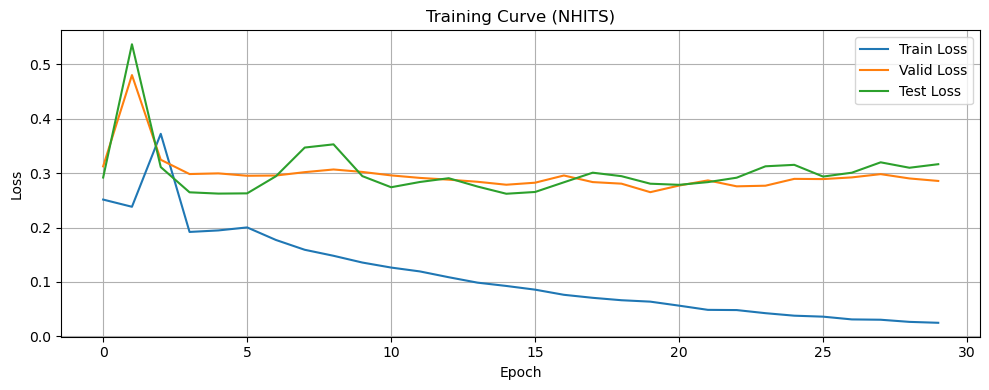

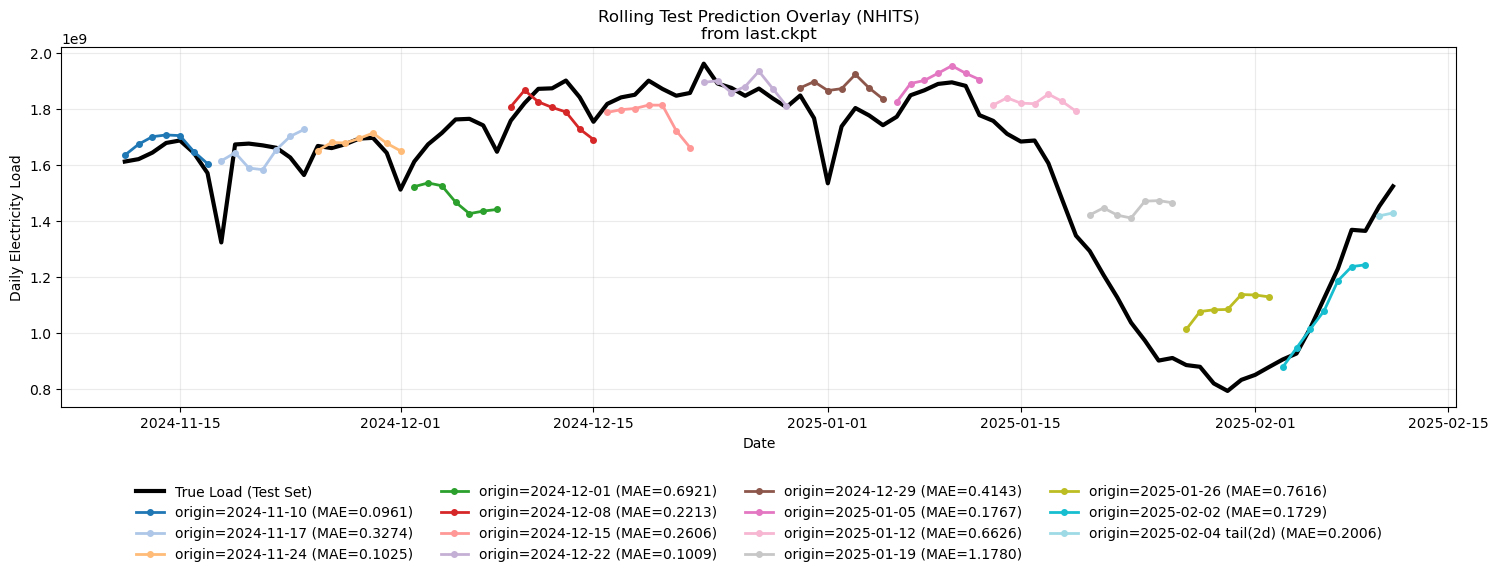

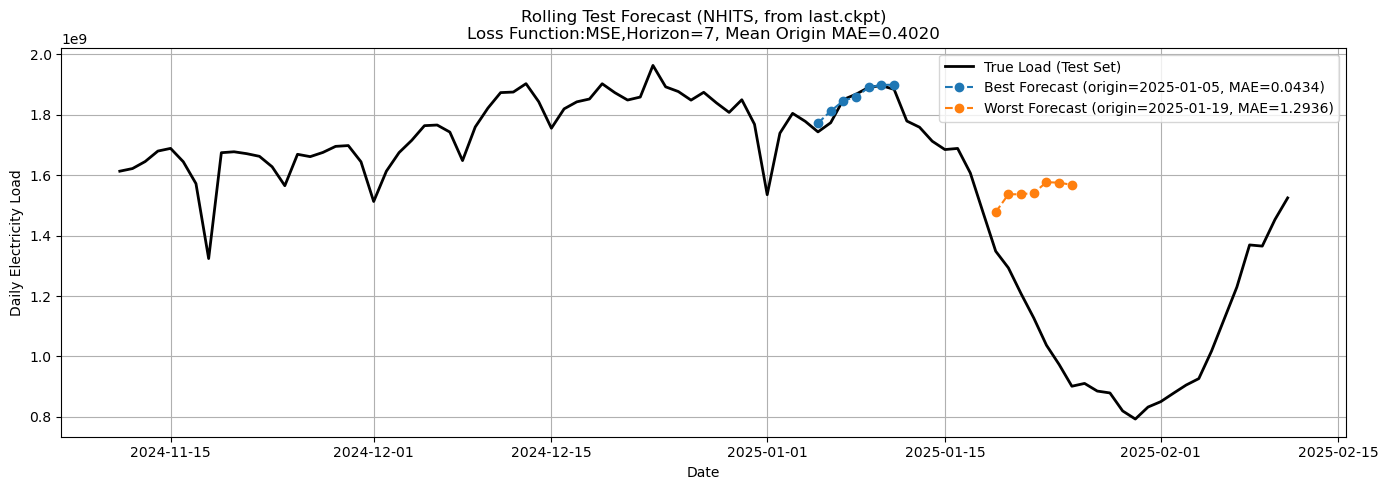

{'model_name': 'NHITS', 'val_overall_mape': 7.5721026862435155, 'overall_mape': 10.161448504102356, 'skipped': False, 'skip_reason': None, 'artifact_dir': 'artifacts\\NHITS_both_feat\\20260420_161552', 'best_model_path': 'artifacts\\NHITS_both_feat\\20260420_161552\\checkpoints\\last.ckpt', 'val_best_model_path': 'artifacts\\NHITS_both_feat\\20260420_161552\\checkpoints\\val_best.ckpt', 'test_best_model_path': None, 'rolling_raw_path': 'artifacts\\NHITS_both_feat\\20260420_161552\\rolling_test_raw.csv', 'overlay_plot_path': 'artifacts\\NHITS_both_feat\\20260420_161552\\rolling_test_overlay.png'}
rolling_raw_path: artifacts\NHITS_both_feat\20260420_161552\rolling_test_raw.csv


In [12]:
from neuralforecast.models import NHITS

nhits_spec = ModelSpec(
    name="NHITS",
    model_type="neural",
    model_cls=NHITS,
    model_params={
        "max_epochs": NEURAL_MAX_EPOCHS,
        "learning_rate": NEURAL_LEARNING_RATE,
    },
    supports_hist_exog=True,
    supports_future_exog=True,
)

nhits_result = run_model(nhits_spec, runner_both_exog)

Seed set to 2026


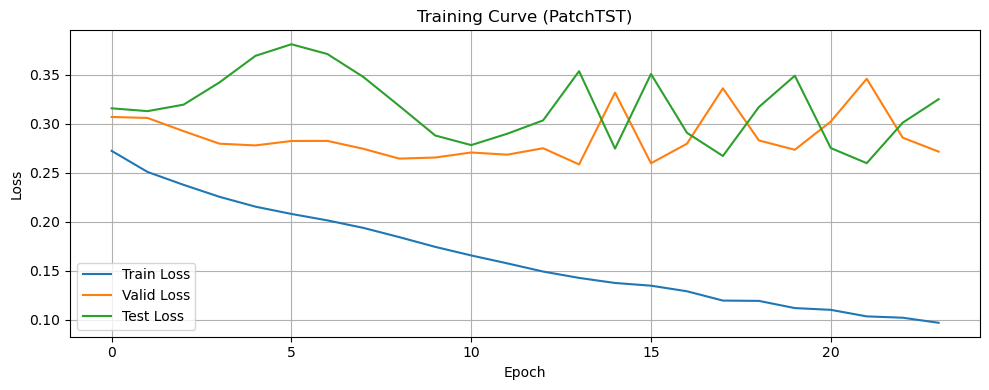

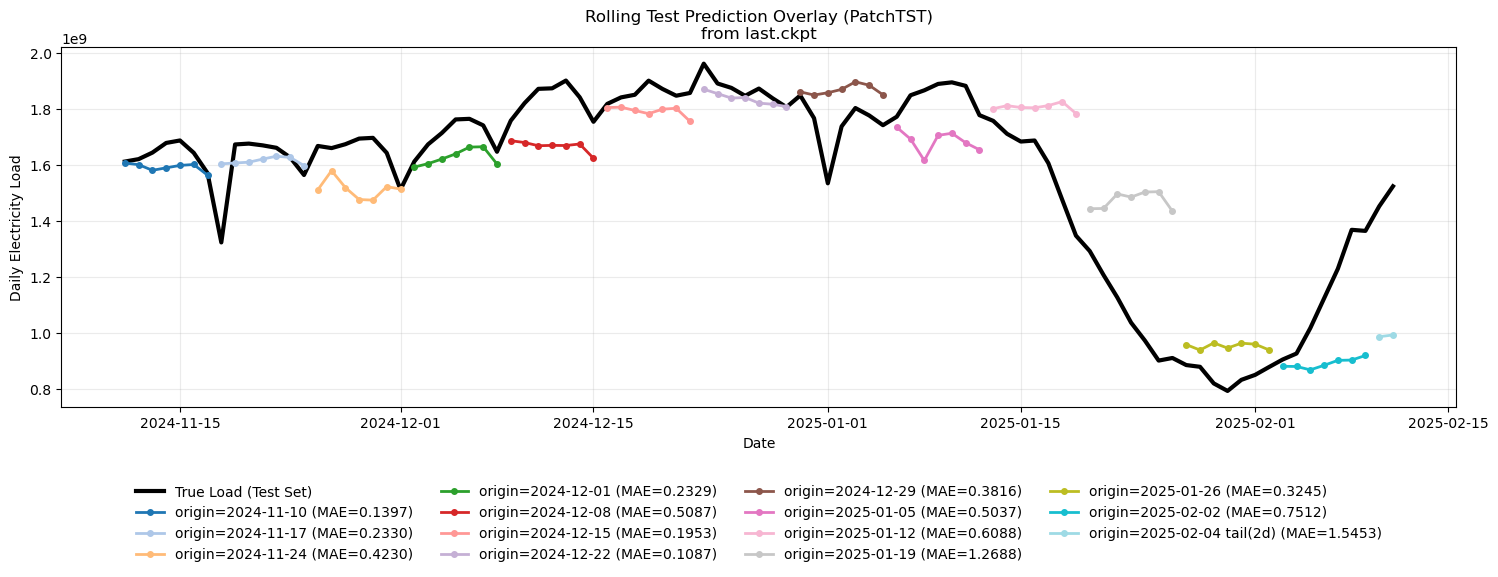

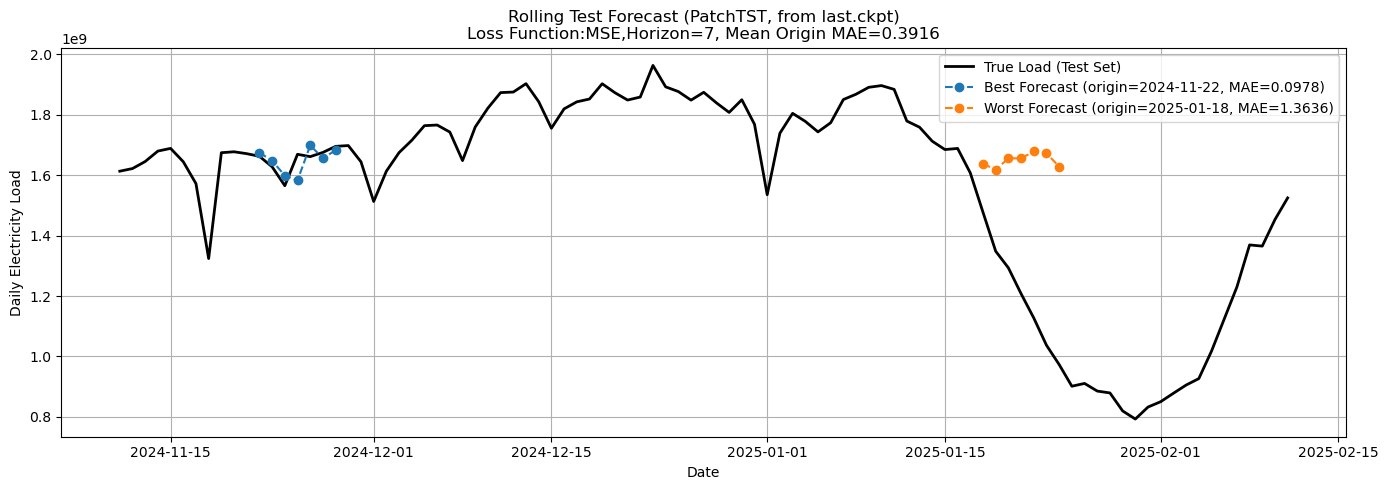

{'model_name': 'PatchTST', 'val_overall_mape': 7.268659101228015, 'overall_mape': 9.666062642302432, 'skipped': False, 'skip_reason': None, 'artifact_dir': 'artifacts\\PatchTST_no_feat\\20260420_135015', 'best_model_path': 'artifacts\\PatchTST_no_feat\\20260420_135015\\checkpoints\\last.ckpt', 'val_best_model_path': 'artifacts\\PatchTST_no_feat\\20260420_135015\\checkpoints\\val_best.ckpt', 'test_best_model_path': None, 'rolling_raw_path': 'artifacts\\PatchTST_no_feat\\20260420_135015\\rolling_test_raw.csv', 'overlay_plot_path': 'artifacts\\PatchTST_no_feat\\20260420_135015\\rolling_test_overlay.png'}
rolling_raw_path: artifacts\PatchTST_no_feat\20260420_135015\rolling_test_raw.csv


In [ ]:
# from neuralforecast.models import PatchTST

# patchtst_spec = ModelSpec(
#     name="PatchTST",
#     model_type="neural",
#     model_cls=PatchTST,
#     model_params={
#         "n_heads": 4,
#         "hidden_size": 128,
#         "dropout": 0.1,
#         "max_epochs": NEURAL_MAX_EPOCHS,
#         "learning_rate": NEURAL_LEARNING_RATE,
#     },
#     supports_hist_exog=False,
#     supports_future_exog=False,
# )

# patchtst_result = run_model(patchtst_spec, runner_no_exog)

Seed set to 2026
d:\miniconda\envs\dl\Lib\site-packages\torch\nn\init.py:511: UserWarning: Initializing zero-element tensors is a no-op
  warnings.warn("Initializing zero-element tensors is a no-op")


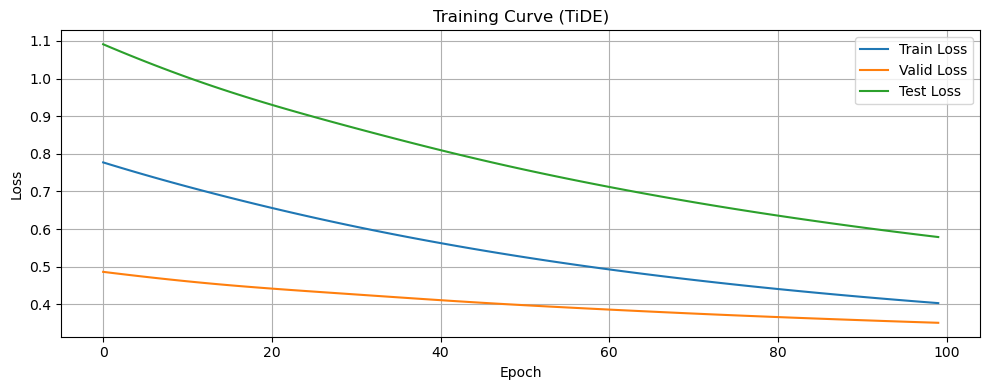

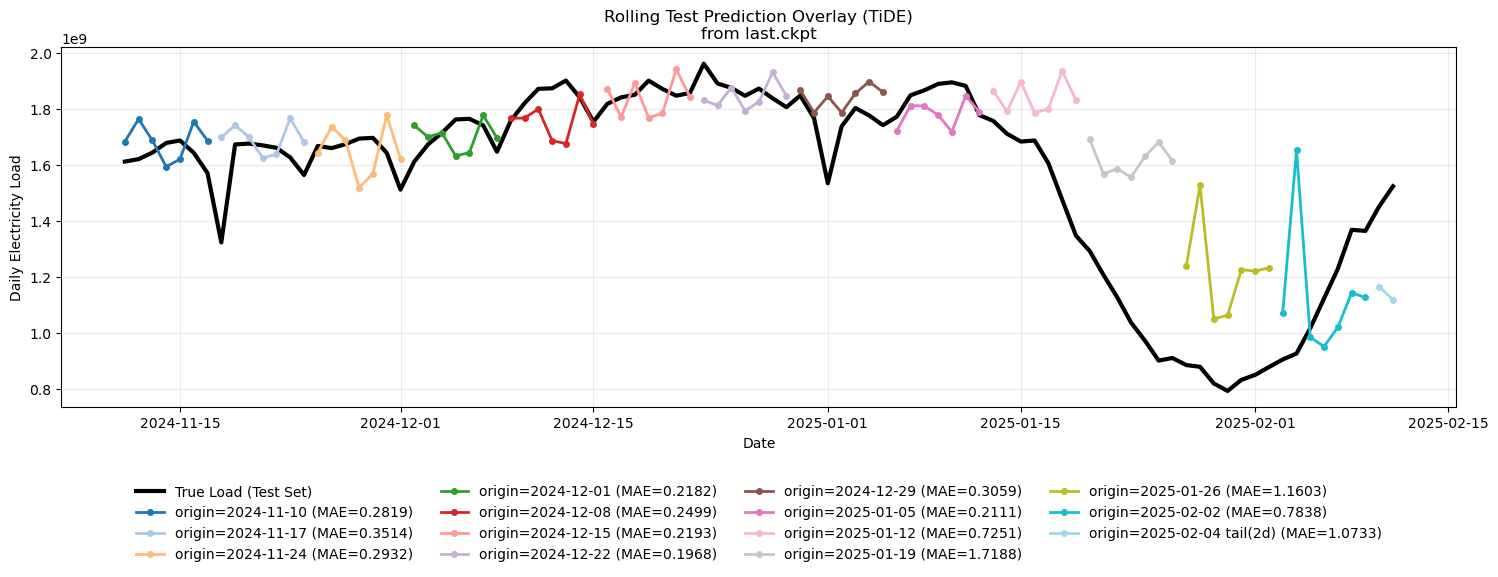

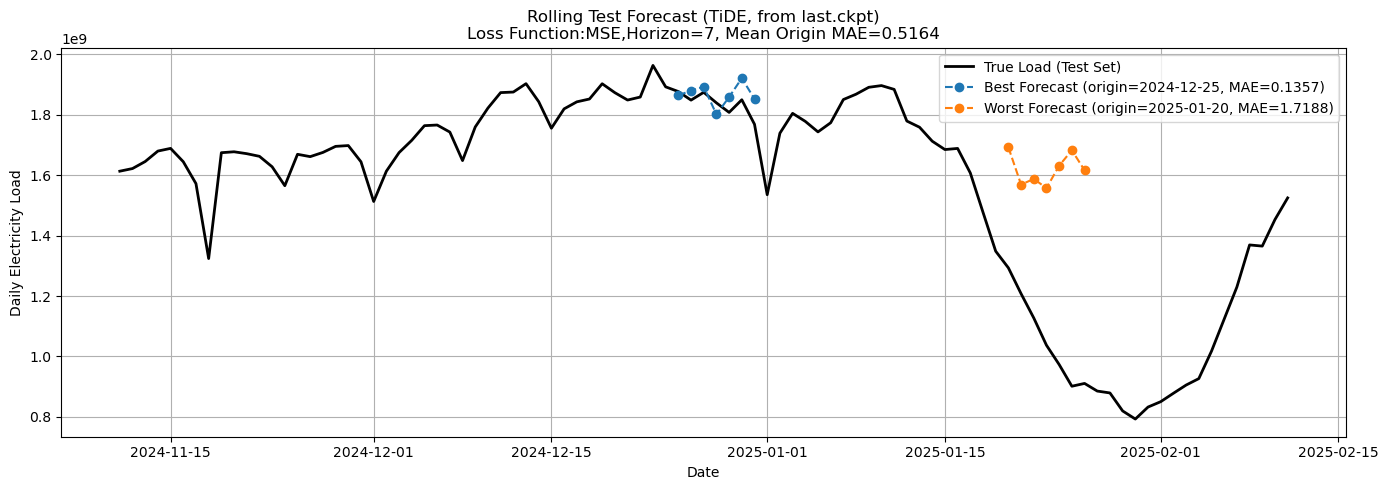

{'model_name': 'TiDE', 'val_overall_mape': 8.991472780999928, 'overall_mape': 14.021479823757948, 'skipped': False, 'skip_reason': None, 'artifact_dir': 'artifacts\\TiDE_futr_feat\\20260420_155546', 'best_model_path': 'artifacts\\TiDE_futr_feat\\20260420_155546\\checkpoints\\last.ckpt', 'val_best_model_path': 'artifacts\\TiDE_futr_feat\\20260420_155546\\checkpoints\\val_best.ckpt', 'test_best_model_path': None, 'rolling_raw_path': 'artifacts\\TiDE_futr_feat\\20260420_155546\\rolling_test_raw.csv', 'overlay_plot_path': 'artifacts\\TiDE_futr_feat\\20260420_155546\\rolling_test_overlay.png'}
rolling_raw_path: artifacts\TiDE_futr_feat\20260420_155546\rolling_test_raw.csv


In [ ]:
# from neuralforecast.models import TiDE

# tide_spec = ModelSpec(
#     name="TiDE",
#     model_type="neural",
#     model_cls=TiDE,
#     model_params={
#         "hidden_size": 128,
#         "decoder_output_dim": 16,
#         "temporal_decoder_dim": 64,
#         "dropout": 0.1,
#         "max_epochs": NEURAL_MAX_EPOCHS,
#         "learning_rate": NEURAL_LEARNING_RATE,
#     },
#     supports_hist_exog=True,
#     supports_future_exog=True,
# )

# tide_result = run_model(tide_spec, runner_futr_exog)

Seed set to 2026


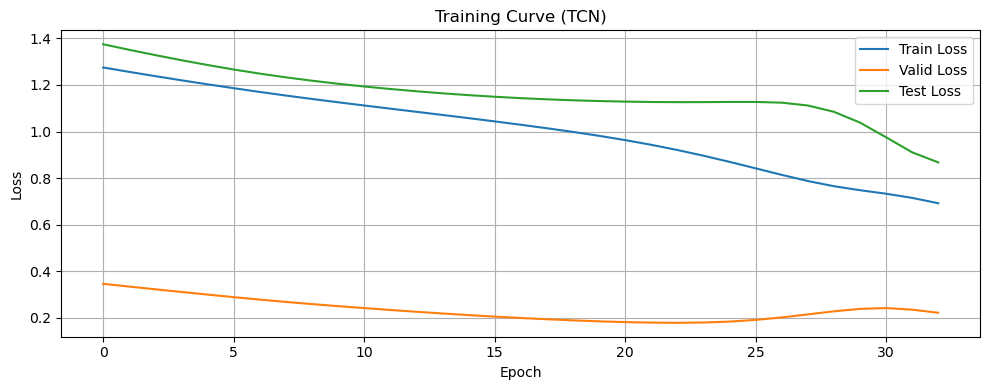

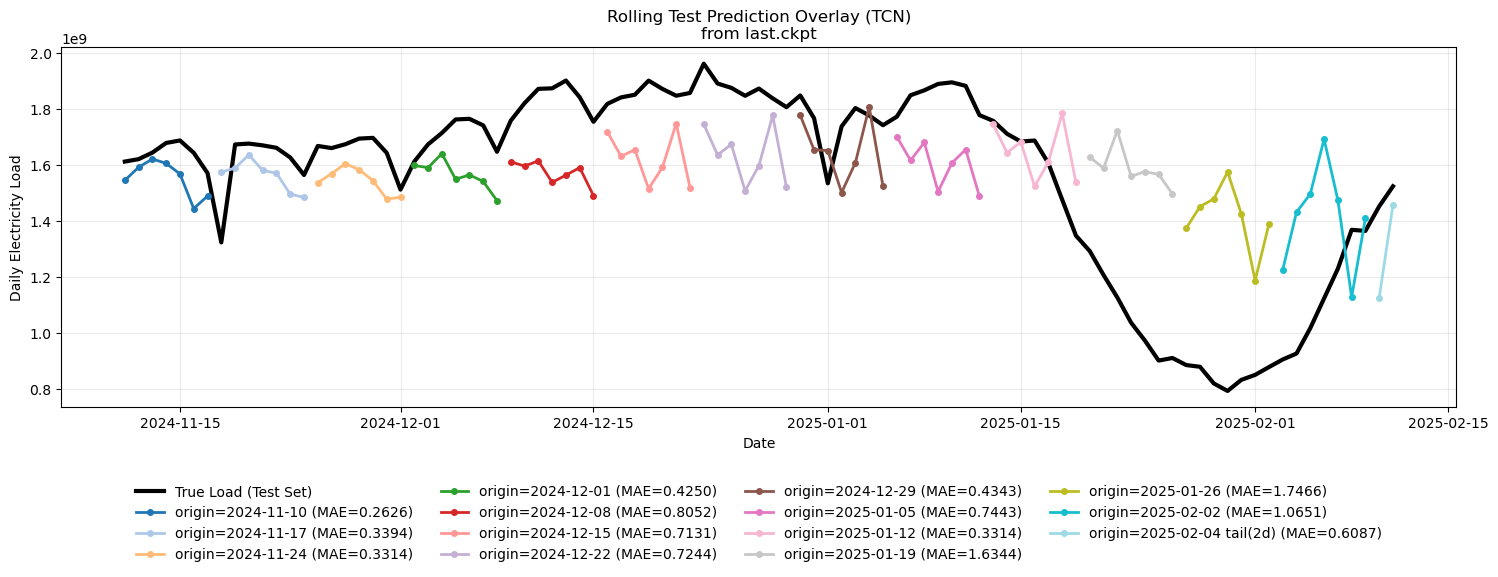

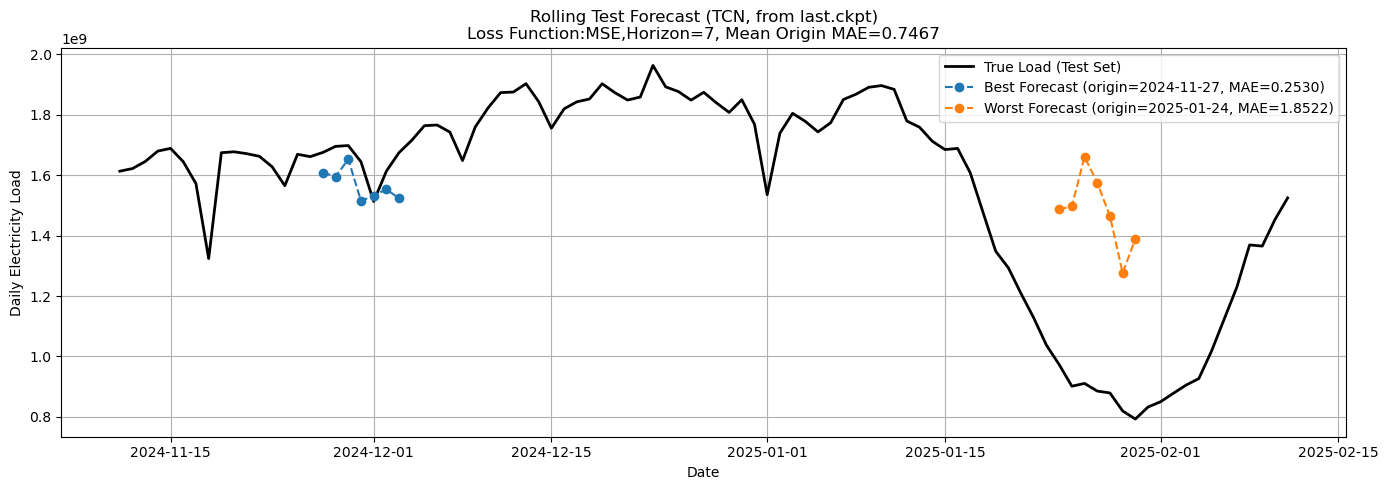

{'model_name': 'TCN', 'val_overall_mape': 5.966295108661915, 'overall_mape': 19.173375704773957, 'skipped': False, 'skip_reason': None, 'artifact_dir': 'artifacts\\TCN_futr_feat\\20260420_160839', 'best_model_path': 'artifacts\\TCN_futr_feat\\20260420_160839\\checkpoints\\last.ckpt', 'val_best_model_path': 'artifacts\\TCN_futr_feat\\20260420_160839\\checkpoints\\val_best.ckpt', 'test_best_model_path': None, 'rolling_raw_path': 'artifacts\\TCN_futr_feat\\20260420_160839\\rolling_test_raw.csv', 'overlay_plot_path': 'artifacts\\TCN_futr_feat\\20260420_160839\\rolling_test_overlay.png'}
rolling_raw_path: artifacts\TCN_futr_feat\20260420_160839\rolling_test_raw.csv


In [ ]:
# from neuralforecast.models import TCN

# tcn_spec = ModelSpec(
#     name="TCN",
#     model_type="neural",
#     model_cls=TCN,
#     model_params={
#         "kernel_size": 2,
#         "dilations": [1, 2, 4, 8],
#         "encoder_hidden_size": 64,
#         "decoder_hidden_size": 64,
#         "decoder_layers": 2,
#         "max_epochs": NEURAL_MAX_EPOCHS,
#         "learning_rate": NEURAL_LEARNING_RATE,
#     },
#     supports_hist_exog=True,
#     supports_future_exog=True,
# )

# tcn_result = run_model(tcn_spec, runner_futr_exog)